# The goal of this notebook is to read in the terra climate data for 2019-2023 and compare with measurements from Naturaleza

In [3]:
import os
import glob
import xarray as xr

# Path to historical data
path = "/Users/szelie/data/unu/terra_climate/"

# Dominican Republic bounding box
LAT_BOUNDS_DR = (20.0, 17.5)
LON_BOUNDS_DR = (-72.0, -68.0)

# Desired years
YEARS = list(range(2018, 2024))

def clip_to_dominican_republic(ds):
    return ds.sel(lat=slice(*LAT_BOUNDS_DR), lon=slice(*LON_BOUNDS_DR))

def file_in_years(filename):
    # Assumes filename ends with _YYYY_CA.nc
    basename = os.path.basename(filename)
    try:
        year = int(basename.split("_")[-2])
        return year in YEARS
    except (IndexError, ValueError):
        return False

def load_monthly_data(path, varname):
    files = sorted(glob.glob(os.path.join(path, f"TerraClimate_{varname}_*_CA.nc")))
    filtered_files = [f for f in files if file_in_years(f)]
    print(f"📂 Loading {len(filtered_files)} files for {varname}")
    data = xr.concat([clip_to_dominican_republic(xr.open_dataset(f)[varname]) for f in filtered_files], dim="time")
    return data

# Load historical data
print(f"\n🚀 Loading historical TerraClimate data (2018–2023)")
tmin = load_monthly_data(path, "tmin")
tmax = load_monthly_data(path, "tmax")
ppt = load_monthly_data(path, "ppt")

tmean = (tmin + tmax) / 2

monthly_data = {
    "tmean": tmean,
    "ppt": ppt
}

print("\n✅ Done: Historical monthly temperature and precipitation data loaded.")



🚀 Loading historical TerraClimate data (2018–2023)
📂 Loading 5 files for tmin
📂 Loading 5 files for tmax
📂 Loading 5 files for ppt

✅ Done: Historical monthly temperature and precipitation data loaded.


### the precipitation data seems to accumulate and at some point reset to 0

In [73]:
import pandas as pd
import os

# Path to your Excel files
base_path = "/Users/szelie/data/unu/microclimate"
years = range(2020, 2024)

all_dfs = []

for year in years:
    file_path = os.path.join(base_path, f"{year}.xlsx")
    xl = pd.ExcelFile(file_path)
    for sheet in xl.sheet_names:
        try:
            df = xl.parse(sheet, skiprows=1)
            df = df.rename(columns=lambda x: str(x).strip())  # remove leading/trailing spaces

            # Flexible detection of datetime column
            datetime_col = next((col for col in df.columns if "Date Time" in col), df.columns[0])

            # Temperature column: exact match or fallback to 3rd column
            temp_col = (
                "Temp, °C (LGR S/N: 20617834, SEN S/N: 20617834, LBL: Temperatura)"
                if "Temp, °C (LGR S/N: 20617834, SEN S/N: 20617834, LBL: Temperatura)" in df.columns
                else df.columns[2]
            )

            df_clean = df[[datetime_col, temp_col, "mm"]].copy()
            df_clean.columns = ["datetime", "temp_C", "precip_mm"]

            df_clean["datetime"] = pd.to_datetime(df_clean["datetime"], errors="coerce", dayfirst=True)
            df_clean["year"] = df_clean["datetime"].dt.year
            df_clean["month"] = df_clean["datetime"].dt.month

            all_dfs.append(df_clean)
        except Exception as e:
            print(f"Skipping sheet {sheet} in {year}: {e}")

# Combine all years
micro_df = pd.concat(all_dfs, ignore_index=True)

# Drop rows with missing datetime or all NaNs
micro_df = micro_df.dropna(subset=["datetime", "temp_C", "precip_mm"], how="all")

# Optional: display head
print(micro_df.head())


Skipping sheet Mayo in 2021: "['mm'] not in index"
Skipping sheet junio in 2021: "['mm'] not in index"
Skipping sheet Agosto in 2021: "['mm'] not in index"
Skipping sheet Septiembre in 2021: "['mm'] not in index"
Skipping sheet Octubre  in 2021: "['mm'] not in index"
Skipping sheet Noviembre  in 2021: "['mm'] not in index"
Skipping sheet Diciembre  in 2021: "['mm'] not in index"
Skipping sheet Mayo in 2022: "['mm'] not in index"
Skipping sheet junio in 2022: "['mm'] not in index"
Skipping sheet Julio in 2022: "['mm'] not in index"
Skipping sheet Agosto in 2022: "['mm'] not in index"
Skipping sheet Septiembre in 2022: "['mm'] not in index"
Skipping sheet Octubre  in 2022: "['mm'] not in index"
Skipping sheet Noviembre  in 2022: "['mm'] not in index"
Skipping sheet Diciembre  in 2022: index 0 is out of bounds for axis 0 with size 0
Skipping sheet Enero in 2023: index 0 is out of bounds for axis 0 with size 0
Skipping sheet Febrero in 2023: index 0 is out of bounds for axis 0 with size 0


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_26529/2837816127.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["datetime"] = pd.to_datetime(df_clean["datetime"], errors="coerce", dayfirst=True)


             datetime  temp_C  precip_mm    year  month
0 2020-01-01 00:00:00  19.092        0.0  2020.0    1.0
1 2020-01-01 00:30:00  18.521        0.0  2020.0    1.0
2 2020-01-01 01:00:00  18.426        0.0  2020.0    1.0
3 2020-01-01 01:30:00  18.045        0.0  2020.0    1.0
4 2020-01-01 02:00:00  17.760        0.0  2020.0    1.0


In [74]:
df

,N.º,"Fecha Tiempo, GMT-04:00","Temp, °C (LGR S/N: 20617833, SEN S/N: 20617833)","Event, units (LGR S/N: 20617833, SEN S/N: 20617833)",Acoplador separado (LGR S/N: 20617833),Acoplador adjunto (LGR S/N: 20617833),Host conectado (LGR S/N: 20617833),Final de archivo (LGR S/N: 20617833),Unnamed: 8,Unnamed: 9,mm
0,10322,2023-12-01 00:48:26,17.475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,10323,2023-12-01 01:48:26,17.094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,10324,2023-12-01 02:48:26,17.189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,10325,2023-12-01 03:48:26,16.903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,10326,2023-12-01 04:48:26,17.094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
66,10388,2023-12-03 08:48:26,19.377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
67,10389,2023-12-03 09:48:26,20.615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
68,10390,2023-12-03 10:48:26,23.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
69,10391,2023-12-03 10:56:20,NaN,NaN,NaN,Registrado,NaN,NaN,NaN,NaN,0.0


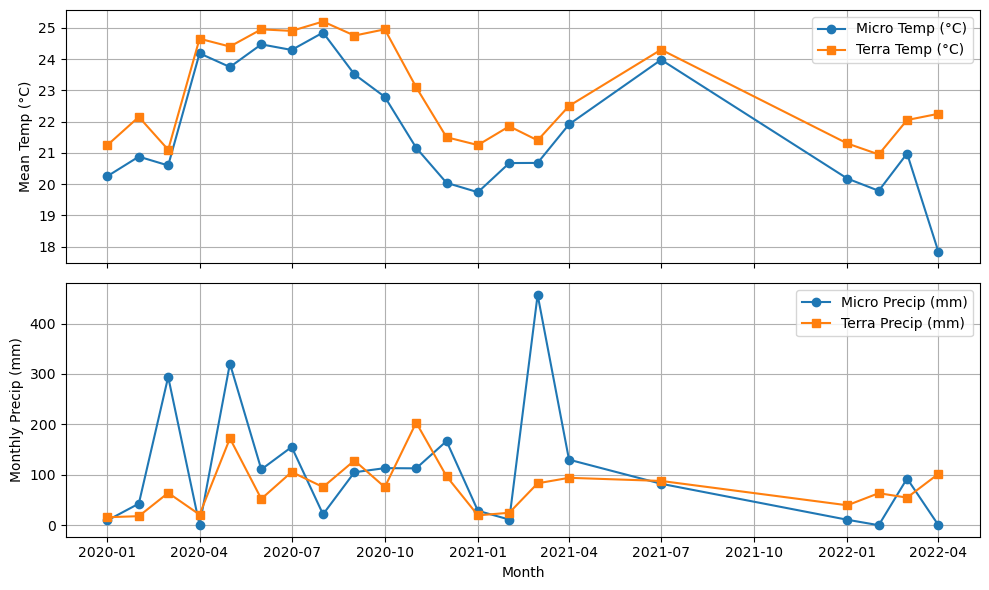

In [75]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Step 1: Clean and aggregate microclimate data
micro_df = micro_df.sort_values("datetime").copy()

# --- Clean cumulative precipitation ---
def clean_cumulative_precip(raw_series):
    raw = raw_series.copy().reset_index(drop=True)
    clean = []
    last_valid = None

    for val in raw:
        if val == 0:
            last_valid = None
            clean.append(0)
        elif last_valid is None:
            last_valid = val
            clean.append(0)
        else:
            diff = val - last_valid
            clean.append(diff if diff > 0 else 0)
            last_valid = val

    return pd.Series(clean, index=raw_series.index)

micro_df["precip_daily"] = clean_cumulative_precip(micro_df["precip_mm"])
micro_df = micro_df.dropna(subset=["precip_daily"])

# --- Monthly aggregation ---
micro_df["month"] = micro_df["datetime"].dt.to_period("M")
micro_monthly = micro_df.groupby("month").agg({
    "temp_C": "mean",
    "precip_daily": "sum"
}).rename(columns={"temp_C": "micro_temp", "precip_daily": "micro_precip"}).reset_index()
micro_monthly["month"] = micro_monthly["month"].dt.to_timestamp()

# Step 2: Load TerraClimate data (already loaded)
terra_tmean = monthly_data["tmean"]
terra_ppt = monthly_data["ppt"]

# Step 3: Extract data at the nearest grid point
lat_pt, lon_pt = 19 + 17/60 + 36.9/3600, - (71 + 15/60 + 7.6/3600)  # ≈ 19.2936, -71.2521
lat_idx = np.abs(terra_tmean.lat - lat_pt).argmin().item()
lon_idx = np.abs(terra_tmean.lon - lon_pt).argmin().item()

terra_monthly_df = pd.DataFrame({
    "month": terra_tmean.time.values,
    "terra_tmean": terra_tmean[:, lat_idx, lon_idx].values,
    "terra_ppt": terra_ppt[:, lat_idx, lon_idx].values
})
terra_monthly_df["month"] = pd.to_datetime(terra_monthly_df["month"])
terra_monthly_df = terra_monthly_df.set_index("month").loc["2020":"2023"].reset_index()

# Step 4: Merge datasets
compare_df = pd.merge(micro_monthly, terra_monthly_df, on="month", how="inner")

# Step 5: Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# --- Temperature plot ---
ax[0].plot(compare_df["month"], compare_df["micro_temp"], label="Micro Temp (°C)", marker="o")
ax[0].plot(compare_df["month"], compare_df["terra_tmean"], label="Terra Temp (°C)", marker="s")
ax[0].set_ylabel("Mean Temp (°C)")
ax[0].legend()
ax[0].grid(True)

# --- Precipitation plot ---
ax[1].plot(compare_df["month"], compare_df["micro_precip"], label="Micro Precip (mm)", marker="o")
ax[1].plot(compare_df["month"], compare_df["terra_ppt"], label="Terra Precip (mm)", marker="s")
ax[1].set_ylabel("Monthly Precip (mm)")
ax[1].legend()
ax[1].grid(True)

plt.xlabel("Month")
plt.tight_layout()
plt.show()


## --> the temperature data alins quite closely. however the precipitation doesnt seem to capture peaks so well, but we would need more data to dobias correction